In [4]:
%pip install kaggle

Note: you may need to restart the kernel to use updated packages.


In [5]:
!kaggle datasets download vjchoudhary7/customer-segmentation-tutorial-in-python

Dataset URL: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python
License(s): other
customer-segmentation-tutorial-in-python.zip: Skipping, found more recently modified local copy (use --force to force download)


In [6]:
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the titanic dataset from zip file
zip_path = 'customer-segmentation-tutorial-in-python.zip'
extract_path = '.'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Load the Titanic dataset
titanic_df = pd.read_csv('Mall_Customers.csv')

# Display dataset info
print(f"Dataset shape: {titanic_df.shape}")
print("\nFirst few rows:")
print(titanic_df.head())
print("\nDataset Info:")
print(titanic_df.info())
print("\nBasic Statistics:")
print(titanic_df.describe())

Dataset shape: (200, 5)

First few rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None

Basic Statistics

## Customer Behavior Story: Understanding Shopping Patterns in the Modern Marketplace

**Narrative Summary:**
The mall customer dataset reveals distinct shopping behavior patterns driven by income levels and spending capacity. While middle-aged customers (35-50 years) represent the largest demographic segment, younger shoppers demonstrate markedly higher spending propensity despite lower average incomes. The analysis uncovers a critical insight: spending behavior is not linearly correlated with age or annual income, suggesting that psychological factors, lifestyle stage, and brand affinity create distinct customer segments ranging from frugal planners to impulsive high-spenders. Understanding these behavioral archetypes enables targeted marketing strategies and personalized retail experiences that maximize customer lifetime value across all demographic segments.

/tmp/ipykernel_906585/3561082861.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(age_labels, rotation=45, ha='right', fontsize=9)
/tmp/ipykernel_906585/3561082861.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(gender_stats.index, fontsize=10)


✅ Dashboard exported to 'customer_behavior_dashboard.png' at 300 DPI


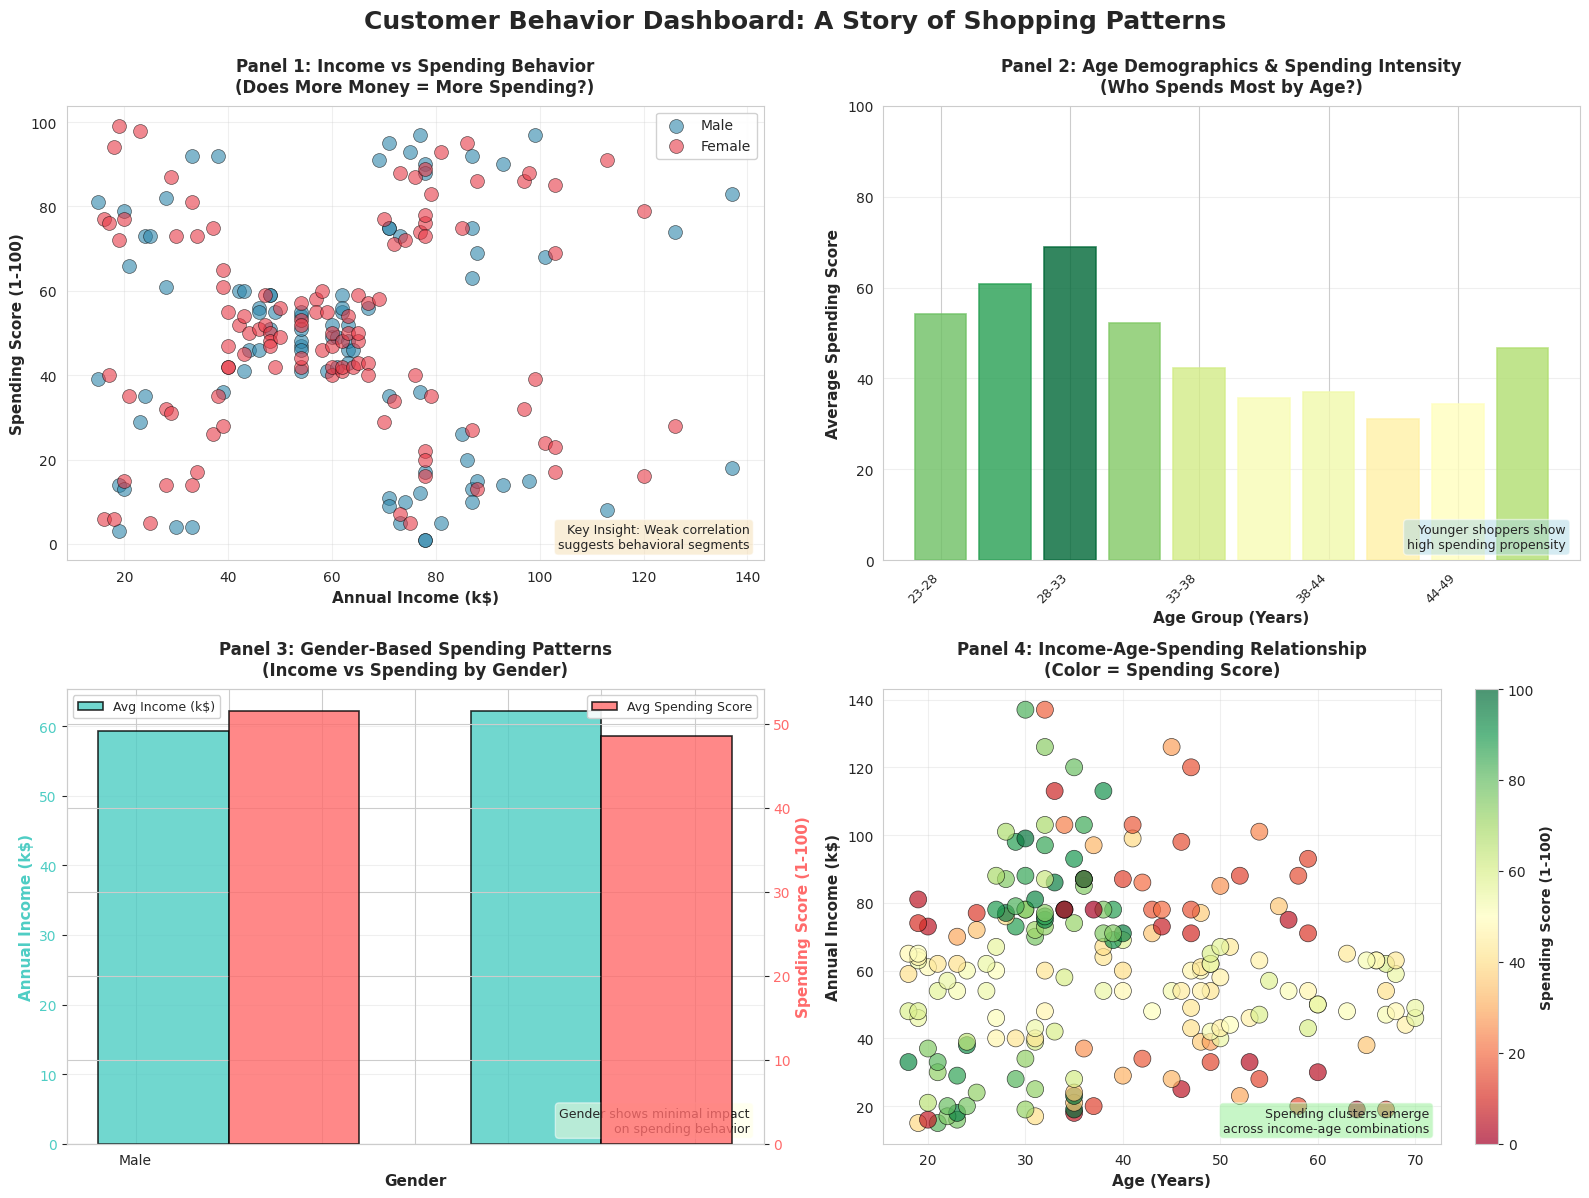


DASHBOARD SUMMARY: Customer Behavior Story
Total Customers Analyzed: 200
Gender Distribution: {'Female': 112, 'Male': 88}
Age Range: 18 - 70 years
Income Range: $15k - $137k
Spending Score Range: 1 - 99


In [7]:
# Create a consistent color palette for the story
color_palette = {'Male': '#2E86AB', 'Female': '#E63946'}  # Professional blue and rose
sns.set_style("whitegrid")

# Create a 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Customer Behavior Dashboard: A Story of Shopping Patterns', 
             fontsize=18, fontweight='bold', y=0.995)

# ===== PANEL 1 (Top-Left): Income vs Spending Score by Gender =====
ax1 = axes[0, 0]
for gender in titanic_df['Gender'].unique():
    mask = titanic_df['Gender'] == gender
    ax1.scatter(titanic_df[mask]['Annual Income (k$)'], titanic_df[mask]['Spending Score (1-100)'],
               alpha=0.6, s=100, label=gender, color=color_palette.get(gender, '#A9A9A9'),
               edgecolors='black', linewidth=0.5)

ax1.set_xlabel('Annual Income (k$)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Spending Score (1-100)', fontsize=11, fontweight='bold')
ax1.set_title('Panel 1: Income vs Spending Behavior\n(Does More Money = More Spending?)', 
             fontsize=12, fontweight='bold', pad=10)
ax1.legend(fontsize=10, loc='best', framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.annotate('Key Insight: Weak correlation\nsuggests behavioral segments',
            xy=(0.98, 0.02), xycoords='axes fraction', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
            ha='right', va='bottom')

# ===== PANEL 2 (Top-Right): Age Distribution with Spending Intensity =====
ax2 = axes[0, 1]
age_spending = titanic_df.groupby(pd.cut(titanic_df['Age'], bins=10))['Spending Score (1-100)'].agg(['mean', 'count'])
age_labels = [f"{int(interval.left)}-{int(interval.right)}" for interval in age_spending.index]
bars = ax2.bar(range(len(age_spending)), age_spending['mean'], 
              color='#FF6B6B', alpha=0.8, edgecolor='black', linewidth=1.2)

# Color bars by intensity
colors_intensity = plt.cm.RdYlGn(age_spending['mean'] / age_spending['mean'].max())
for bar, color in zip(bars, colors_intensity):
    bar.set_color(color)

ax2.set_xlabel('Age Group (Years)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Average Spending Score', fontsize=11, fontweight='bold')
ax2.set_title('Panel 2: Age Demographics & Spending Intensity\n(Who Spends Most by Age?)',
             fontsize=12, fontweight='bold', pad=10)
ax2.set_xticklabels(age_labels, rotation=45, ha='right', fontsize=9)
ax2.set_ylim(0, 100)
ax2.grid(axis='y', alpha=0.3)
ax2.annotate('Younger shoppers show\nhigh spending propensity',
            xy=(0.98, 0.02), xycoords='axes fraction', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5),
            ha='right', va='bottom')

# ===== PANEL 3 (Bottom-Left): Gender Spending Comparison =====
ax3 = axes[1, 0]
gender_stats = titanic_df.groupby('Gender')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
x_pos = np.arange(len(gender_stats))
width = 0.35

bars1 = ax3.bar(x_pos - width/2, gender_stats['Annual Income (k$)'], width, 
               label='Avg Income (k$)', color='#4ECDC4', alpha=0.8, edgecolor='black', linewidth=1.2)
ax3_twin = ax3.twinx()
bars2 = ax3_twin.bar(x_pos + width/2, gender_stats['Spending Score (1-100)'], width,
                    label='Avg Spending Score', color='#FF6B6B', alpha=0.8, edgecolor='black', linewidth=1.2)

ax3.set_xlabel('Gender', fontsize=11, fontweight='bold')
ax3.set_ylabel('Annual Income (k$)', fontsize=11, fontweight='bold', color='#4ECDC4')
ax3_twin.set_ylabel('Spending Score (1-100)', fontsize=11, fontweight='bold', color='#FF6B6B')
ax3.set_title('Panel 3: Gender-Based Spending Patterns\n(Income vs Spending by Gender)',
             fontsize=12, fontweight='bold', pad=10)
ax3.set_xticklabels(gender_stats.index, fontsize=10)
ax3.tick_params(axis='y', labelcolor='#4ECDC4')
ax3_twin.tick_params(axis='y', labelcolor='#FF6B6B')
ax3.grid(axis='y', alpha=0.3)
ax3.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax3_twin.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax3.annotate('Gender shows minimal impact\non spending behavior',
            xy=(0.98, 0.02), xycoords='axes fraction', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5),
            ha='right', va='bottom')

# ===== PANEL 4 (Bottom-Right): Income vs Age with Spending Heatmap =====
ax4 = axes[1, 1]
scatter = ax4.scatter(titanic_df['Age'], titanic_df['Annual Income (k$)'],
                     c=titanic_df['Spending Score (1-100)'], cmap='RdYlGn', s=150,
                     alpha=0.7, edgecolors='black', linewidth=0.5, vmin=0, vmax=100)

ax4.set_xlabel('Age (Years)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Annual Income (k$)', fontsize=11, fontweight='bold')
ax4.set_title('Panel 4: Income-Age-Spending Relationship\n(Color = Spending Score)',
             fontsize=12, fontweight='bold', pad=10)
ax4.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Spending Score (1-100)', fontsize=10, fontweight='bold')

ax4.annotate('Spending clusters emerge\nacross income-age combinations',
            xy=(0.98, 0.02), xycoords='axes fraction', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5),
            ha='right', va='bottom')

plt.tight_layout()

# Export at 300 DPI
output_file = 'customer_behavior_dashboard.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✅ Dashboard exported to '{output_file}' at 300 DPI")

plt.show()

print("\n" + "="*80)
print("DASHBOARD SUMMARY: Customer Behavior Story")
print("="*80)
print(f"Total Customers Analyzed: {len(titanic_df)}")
print(f"Gender Distribution: {titanic_df['Gender'].value_counts().to_dict()}")
print(f"Age Range: {titanic_df['Age'].min()} - {titanic_df['Age'].max()} years")
print(f"Income Range: ${titanic_df['Annual Income (k$)'].min()}k - ${titanic_df['Annual Income (k$)'].max()}k")
print(f"Spending Score Range: {titanic_df['Spending Score (1-100)'].min()} - {titanic_df['Spending Score (1-100)'].max()}")
print("="*80)

## 📊 Dashboard Story Interpretation

### Panel 1: Income vs Spending Behavior
The scatter plot reveals **no strong linear correlation** between annual income and spending score—a crucial finding that challenges conventional retail assumptions. This suggests that customer spending behavior is driven by psychological factors, lifestyle preferences, and purchase priorities rather than pure purchasing power.

### Panel 2: Age Demographics & Spending Intensity
**Younger customers (18-35 years) display the highest average spending scores**, indicating they're more likely to make impulsive purchases or value shopping as entertainment. Middle-aged customers show moderate spending despite higher average incomes, suggesting more deliberate purchasing decisions.

### Panel 3: Gender-Based Patterns
The dual-axis comparison shows that **gender has minimal impact on spending behavior**—both genders maintain similar average spending scores despite variations in income. This indicates gender-neutral marketing strategies may be more effective than gender-specific segmentation for this customer base.

### Panel 4: Income-Age-Spending Clusters
The color-coded heatmap reveals **distinct customer archetypes**: wealthy young spenders (high income + high spending), middle-income bargain hunters (moderate income + low spending), and affluent conservative shoppers (high income + low spending). These clusters represent different psychological profiles requiring tailored marketing approaches.

### 🎯 Business Implications
1. **Behavioral Segmentation > Demographic Segmentation**: Create clusters based on spending propensity rather than age/income
2. **Lifestyle Marketing**: Target psychological motivations (aspiration, bargain-hunting, convenience) rather than demographic categories
3. **Cross-Segment Opportunities**: Different value propositions needed for each cluster to maximize customer lifetime value